# Chapter 7

## 7.1 backends

In [9]:
from qiskit_ibm_runtime import QiskitRuntimeService
IBM_API_TOKEN = 'M6y8EOoLDf0Bt_-iakd5Tv1K2J2blj4x_p0nM_XPiNbO'
QiskitRuntimeService.save_account(IBM_API_TOKEN, overwrite=True)

In [10]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService()

print("Active account:", service.active_account())
print("\nAvailable backends:")
for backend in service.backends(simulator=True):
    print(f"- {backend.name} | Status: {backend.status().operational}")

qiskit_runtime_service.__init__:WARNING:2026-01-04 11:11:18,305: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-04 11:11:18,309: Loading instance: open-instance, plan: open


Active account: {'channel': 'ibm_quantum_platform', 'url': 'https://cloud.ibm.com', 'token': 'M6y8EOoLDf0Bt_-iakd5Tv1K2J2blj4x_p0nM_XPiNbO', 'verify': True, 'private_endpoint': False}

Available backends:


In [11]:
from qiskit_aer import Aer
aer_backends = Aer.backends()
for i, j in enumerate(aer_backends):
    print("the {} aer backend is {}".format(i, j)) # 前8个是新的，后面的不要用了.

the 0 aer backend is AerSimulator('aer_simulator')
the 1 aer backend is AerSimulator('aer_simulator_statevector')
the 2 aer backend is AerSimulator('aer_simulator_density_matrix')
the 3 aer backend is AerSimulator('aer_simulator_stabilizer')
the 4 aer backend is AerSimulator('aer_simulator_matrix_product_state')
the 5 aer backend is AerSimulator('aer_simulator_extended_stabilizer')
the 6 aer backend is AerSimulator('aer_simulator_unitary')
the 7 aer backend is AerSimulator('aer_simulator_superop')
the 8 aer backend is QasmSimulator('qasm_simulator')
the 9 aer backend is StatevectorSimulator('statevector_simulator')
the 10 aer backend is UnitarySimulator('unitary_simulator')


## 7.2 compare with aer and real quantum computer

the depth of the transpiled circuit is: 2


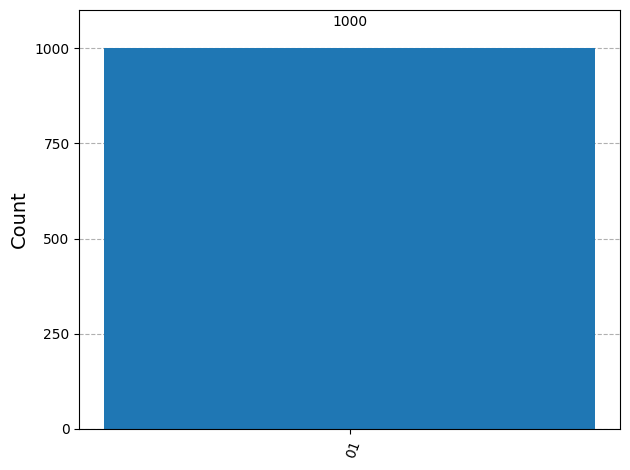

In [34]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

circ = QuantumCircuit(2, 2)
circ.x([0])
for i in range(64):
    circ.swap(0, 1)
    circ.barrier()
circ.measure([0, 1], [0, 1]) 
#display(circ.draw('mpl'))
backend = Aer.get_backend('aer_simulator') 
transpiled_circ = transpile(circ, backend) 
print("the depth of the transpiled circuit is:", transpiled_circ.depth())
#display(transpiled_circ.draw('mpl'))
job = backend.run(transpiled_circ, shots=1000) 
result = job.result() 
counts = result.get_counts()
plot_histogram(counts)

In [ ]:
from quark import Task
import os
from qiskit import qasm2
import time
import matplotlib.pyplot as plt

def quark_comp(qiskit_circ, repeat_count=1, my_job='my_job', chip='Yudu', target_qubits=[]):
    # circ trans
    qasm_circ = qasm2.dumps(qiskit_circ)
    # tmgr
    token = os.getenv('QUARK_API_TOKEN')
    tmgr = Task(token) # task manager
    task = {
    'chip': chip,  
    'name': my_job,  
    'circuit':qasm_circ, # circuit written in OpenQASM2.0
    'compile': True, # (你要是自信自己写的全是基础门就用False.)
    'options':{
        'correct': False,
        'target_qubits': target_qubits # 具体bit而非范围。 
        }
    }

    tid = tmgr.run(task, repeat=repeat_count) # shots = repeat*1024
    res = tmgr.result(tid)
    while not res: # 直到非空再返回
        time.sleep(1)
        res = tmgr.result(tid)
    display(res)

    data = res['count']
    bases = sorted(data) # 00, 01, 10, 11
    count = [data[base] for base in bases]
    plt.bar(bases, count)
    plt.xticks(rotation=45)
    return data

In [28]:
from quark import Task
import os
token = os.getenv('QUARK_API_TOKEN')
tmgr = Task(token)
display(tmgr.status())

{'Baihua': 1,
 'Yudu': 0,
 'Dongling': 0,
 'Haituo': 0,
 'Baiwang': 0,
 'Fenghuang': 0,
 'Haituo-2': 'Maintenance',
 'Hongluo': 'Calibrating',
 'Jiu': 'Maintenance',
 'Ling': 'Maintenance',
 'Lingkai-1': 'Calibrating',
 'Lingkai-2': 'Calibrating',
 'Miaofeng': 'Maintenance',
 'Shenglian': 'Calibrating',
 'Xiang': 'Maintenance'}

{'count': {'01': 220, '00': 319, '11': 229, '10': 256},
 'corrected': {},
 'chip': 'Baihua',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nx q[0];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0]

{'01': 220, '00': 319, '11': 229, '10': 256}

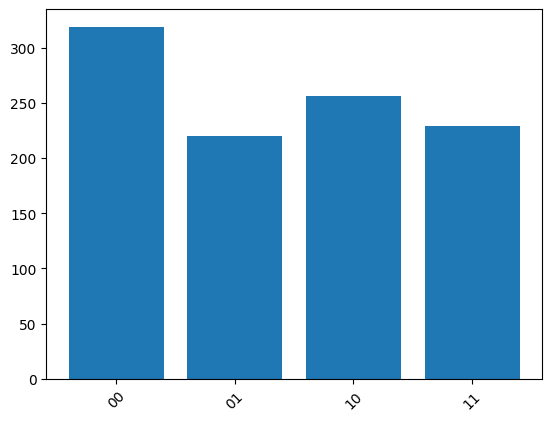

In [29]:
quark_comp(circ, chip='Baihua')

{'count': {'10': 258, '11': 217, '01': 283, '00': 266},
 'corrected': {},
 'chip': 'Yudu',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nx q[0];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q

{'10': 258, '11': 217, '01': 283, '00': 266}

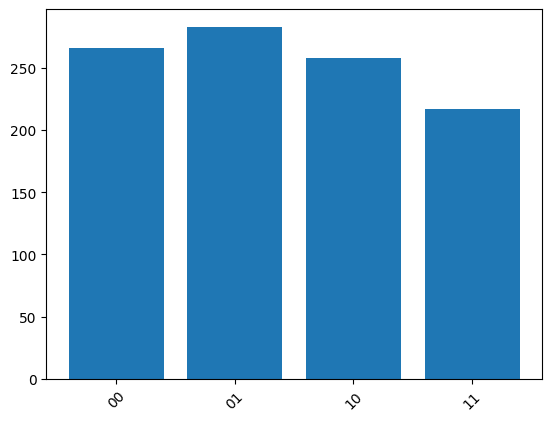

In [30]:
quark_comp(circ, chip='Yudu')

{'count': {'11': 345, '01': 268, '00': 183, '10': 228},
 'corrected': {},
 'chip': 'Dongling',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nx q[0];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[

{'11': 345, '01': 268, '00': 183, '10': 228}

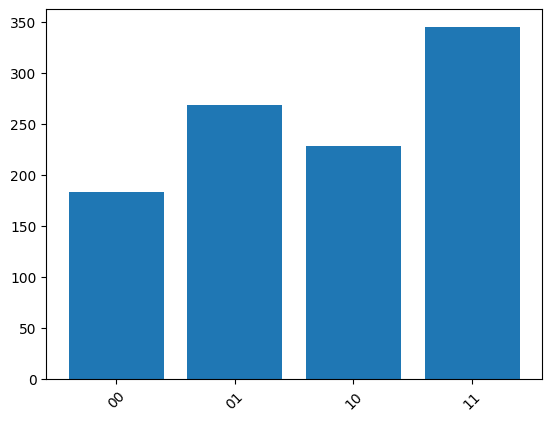

In [31]:
quark_comp(circ, chip='Dongling')

{'count': {'10': 296, '00': 204, '01': 229, '11': 295},
 'corrected': {},
 'chip': 'Haituo',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nx q[0];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0],q[1];\nbarrier q[0],q[1];\nswap q[0]

{'10': 296, '00': 204, '01': 229, '11': 295}

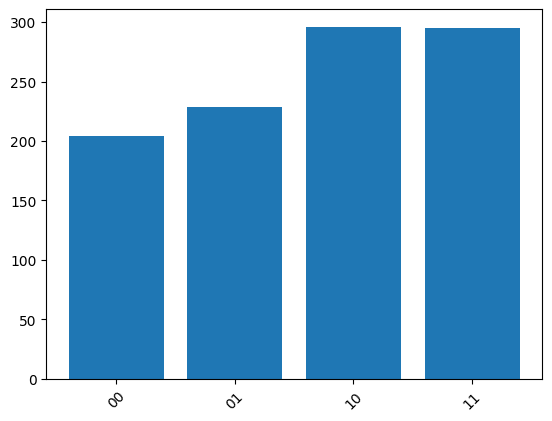

In [32]:
quark_comp(circ, chip='Haituo')

In [22]:
quark_comp(circ, chip='Baiwang')

{'chip': 'Baiwang'}

KeyError: 'count'

In [20]:
quark_comp(circ, chip='Fenghuang')

{'chip': 'Fenghuang'}

KeyError: 'count'

## 7.3 add noise to aer

应该也可以添加真实的量子计算机模型，但是我的api不可以。

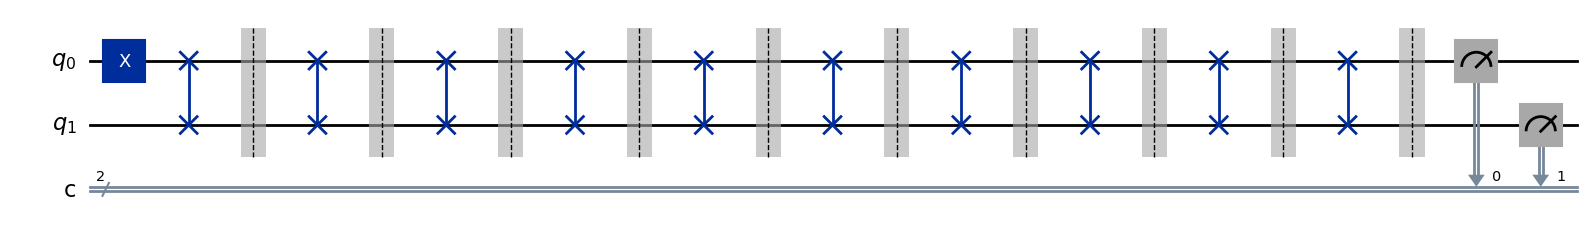

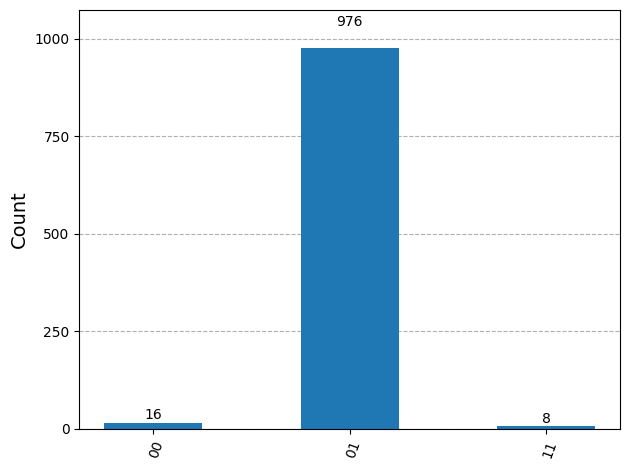

In [15]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit_aer.noise import NoiseModel, depolarizing_error  # 导入噪声相关模块
from qiskit.visualization import plot_histogram

circ = QuantumCircuit(2, 2)
circ.x([0])
for i in range(10):
    circ.swap(0, 1)
    circ.barrier()
circ.measure([0, 1], [0, 1]) 
display(circ.draw('mpl'))

# 创建噪声模型
noise_model = NoiseModel()
# 添加单量子门错误
depolarizing_error_1q = depolarizing_error(0.01, 1) # 参数表示错误率，比特数。 
noise_model.add_all_qubit_quantum_error(depolarizing_error_1q, ['u1', 'u2', 'u3'])
# 添加双量子门错误
depolarizing_error_2q = depolarizing_error(0.1, 2)  
noise_model.add_all_qubit_quantum_error(depolarizing_error_2q, ['cx', 'swap'])
# 添加测量错误
noise_model.add_all_qubit_readout_error([[0.99, 0.01], [0.02, 0.98]])  # 读出错误率(0读出为1的概率为0.01, 1读出为0的概率为0.02)，每一行需要归一化。


# 获取带噪声的模拟器
backend = Aer.get_backend('aer_simulator') 
backend.set_options(noise_model=noise_model)  # 设置噪声模型
transpiled_circ = transpile(circ, backend) 

# 运行带噪声的模拟
job = backend.run(transpiled_circ, shots=1000) 
result = job.result() 
counts = result.get_counts()
plot_histogram(counts)

## 7.4 aer_simulator_statevector and aer_simulator_unitary

新版需要save, 然而每种后端的save只能用一次。。。

Q 球和statevector用一个后端。

Statevector([0.92387953+0.j, 0.38268343+0.j, 0.        +0.j,
             0.        +0.j],
            dims=(2, 2))
Operator([[ 0.92387953+0.j, -0.38268343+0.j,  0.        +0.j,
            0.        +0.j],
          [ 0.38268343+0.j,  0.92387953+0.j,  0.        +0.j,
            0.        +0.j],
          [ 0.        +0.j,  0.        +0.j,  0.92387953+0.j,
           -0.38268343+0.j],
          [ 0.        +0.j,  0.        +0.j,  0.38268343+0.j,
            0.92387953+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


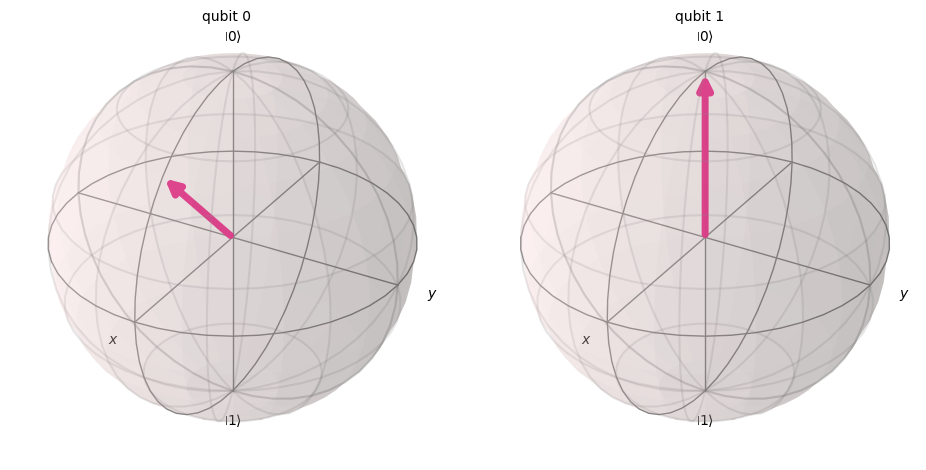

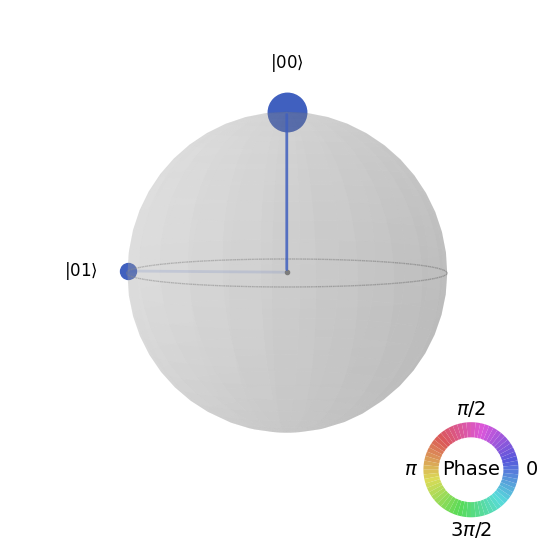

In [16]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere
import numpy as np

circ = QuantumCircuit(2, 2)
circ.ry(np.pi/4, 0)

# 这个电路力只能用于一个后端，莫名其妙。
vec_circ = circ.copy()  # 复制原始电路
vec_circ.save_statevector()  # 只保存态矢量
# 为幺正矩阵模拟创建独立电路  
unitary_circ = circ.copy()  # 复制原始电路
unitary_circ.save_unitary()  # 只保存幺正矩阵
# 获取后端
vec_backend = Aer.get_backend('aer_simulator_statevector')
unitary_backend = Aer.get_backend('aer_simulator_unitary')

vec_result = vec_backend.run(vec_circ).result()
unitary_result = unitary_backend.run(unitary_circ).result()
psi = vec_result.get_statevector()  # 现在可以正确获取
unitary_matrix = unitary_result.get_unitary()
print(psi)
print(unitary_matrix)
display(plot_bloch_multivector(psi))
display(plot_state_qsphere(psi))

## Q sphere

* 相同纬线代表汉明值相同：汉明值指的是量子态基态表示中二进制字符串中值为1的位置数量。
* 相位一般只考虑相对相位，$|\psi\rangle =\alpha e^{i\theta_1} |000\rangle + \beta e^{i\theta_2}|001\rangle + ...$ , **提出第一项系数即为相对相位， 也即$\theta_2 - \theta_1$**。**Q球这个是又在 $[0, 2\pi]$ 归一化处理了。**

Statevector([0.25-0.25j, 0.25+0.25j, 0.25-0.25j, 0.25+0.25j, 0.25-0.25j,
             0.25+0.25j, 0.25-0.25j, 0.25+0.25j],
            dims=(2, 2, 2))


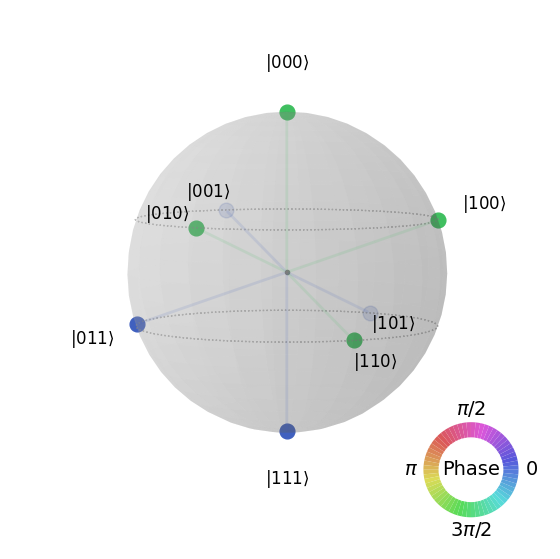

In [17]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_state_qsphere
import numpy as np

circ = QuantumCircuit(3, 3)
circ.h([0, 1, 2])
circ.rz(np.pi/2, 0)

# 这个电路力只能用于一个后端，莫名其妙。
vec_circ = circ.copy()  # 复制原始电路
vec_circ.save_statevector()  # 只保存态矢量
# 获取后端
vec_backend = Aer.get_backend('aer_simulator_statevector')

vec_result = vec_backend.run(vec_circ).result()
psi = vec_result.get_statevector()  # 现在可以正确获取
print(psi)
display(plot_state_qsphere(psi))

颜色有点奇怪，验证一下。

**显然Q球是相对相位，自动在范围内归一化。**

Statevector([0.5-0.5j, 0.5+0.5j],
            dims=(2,))


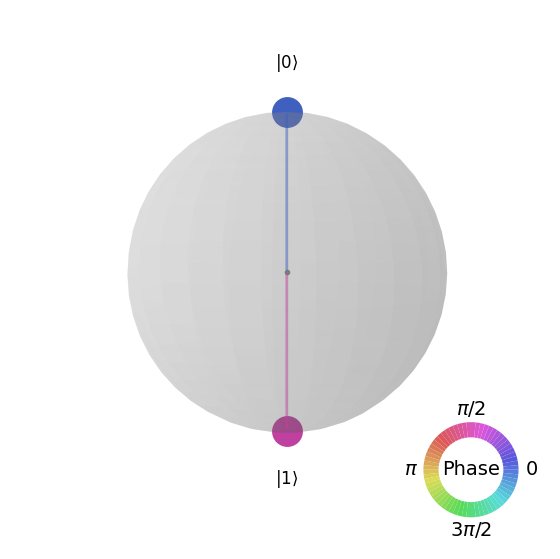

In [18]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_state_qsphere, plot_bloch_multivector 
import numpy as np

circ = QuantumCircuit(1, 1)
circ.h([0])
circ.rz(np.pi/2, 0)

# 这个电路力只能用于一个后端，莫名其妙。
vec_circ = circ.copy()  # 复制原始电路
vec_circ.save_statevector()  # 只保存态矢量
# 获取后端
vec_backend = Aer.get_backend('aer_simulator_statevector')

vec_result = vec_backend.run(vec_circ).result()
psi = vec_result.get_statevector()  # 现在可以正确获取
print(psi)
display(plot_state_qsphere(psi))